# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

   Data yang digunakan berupa data House Price Prediction dari kaggle.

   https://www.kaggle.com/code/ainurrohmanbwx/house-price-prediction-eda-linear-regression/notebook




# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [46]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [47]:
df_raw = pd.read_excel('DATA RUMAH.xlsx', sheet_name='Sheet1')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   NO          1010 non-null   int64 
 1   NAMA RUMAH  1010 non-null   object
 2   HARGA       1010 non-null   int64 
 3   LB          1010 non-null   int64 
 4   LT          1010 non-null   int64 
 5   KT          1010 non-null   int64 
 6   KM          1010 non-null   int64 
 7   GRS         1010 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 63.3+ KB


Explanation of each attribute:
1.   Nama Rumah = House name
2.   LB = Total Building Area
3.   LT = Total Land Area
4.   KT = Number of Bedrooms
5.   KM = Number of Bathrooms
6.   GRS = Number of Car Capacity in the Garage
7.   Harga = House prices (IDR)



In [48]:
df_raw.describe()

,NO,HARGA,LB,LT,KT,KM,GRS
count,1010.000000,1.010000e+03,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000
mean,505.500000,7.628987e+09,276.539604,237.432673,4.668317,3.607921,1.920792
std,291.706188,7.340946e+09,177.864557,179.957604,1.572776,1.420066,1.510998
min,1.000000,4.300000e+08,40.000000,25.000000,2.000000,1.000000,0.000000
25%,253.250000,3.262500e+09,150.000000,130.000000,4.000000,3.000000,1.000000
50%,505.500000,5.000000e+09,216.500000,165.000000,4.000000,3.000000,2.000000
75%,757.750000,9.000000e+09,350.000000,290.000000,5.000000,4.000000,2.000000
max,1010.000000,6.500000e+10,1126.000000,1400.000000,10.000000,10.000000,10.000000


In [49]:
df_raw.head()

,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS
0,1,"Rumah Murah Hook Tebet Timur, Tebet, Jakarta S...",3800000000,220,220,3,3,0
1,2,"Rumah Modern di Tebet dekat Stasiun, Tebet, Ja...",4600000000,180,137,4,3,2
2,3,"Rumah Mewah 2 Lantai Hanya 3 Menit Ke Tebet, T...",3000000000,267,250,4,4,4
3,4,"Rumah Baru Tebet, Tebet, Jakarta Selatan",430000000,40,25,2,2,0
4,5,"Rumah Bagus Tebet komp Gudang Peluru lt 350m, ...",9000000000,400,355,6,5,3


In [50]:
#Ambil hanya data yang akan dipakai saja
df = df_raw.loc[:,['LB', 'LT', 'KT', 'KM', 'GRS', 'HARGA']]

In [51]:
df.rename(columns={'LB': 'Luas Bangunan',
                   'LT': 'Luas Tanah',
                   'KT': 'Kamar Tidur',
                   'KM': 'Kamar Mandi',
                   'GRS': 'Garasi', }, inplace=True)

In [52]:
df.head()

,Luas Bangunan,Luas Tanah,Kamar Tidur,Kamar Mandi,Garasi,HARGA
0,220,220,3,3,0,3800000000
1,180,137,4,3,2,4600000000
2,267,250,4,4,4,3000000000
3,40,25,2,2,0,430000000
4,400,355,6,5,3,9000000000


# **4. Exploratory Data Analysis (EDA)**

In [54]:
print(df.isnull().sum())

Luas Bangunan    0
Luas Tanah       0
Kamar Tidur      0
Kamar Mandi      0
Garasi           0
HARGA            0
dtype: int64


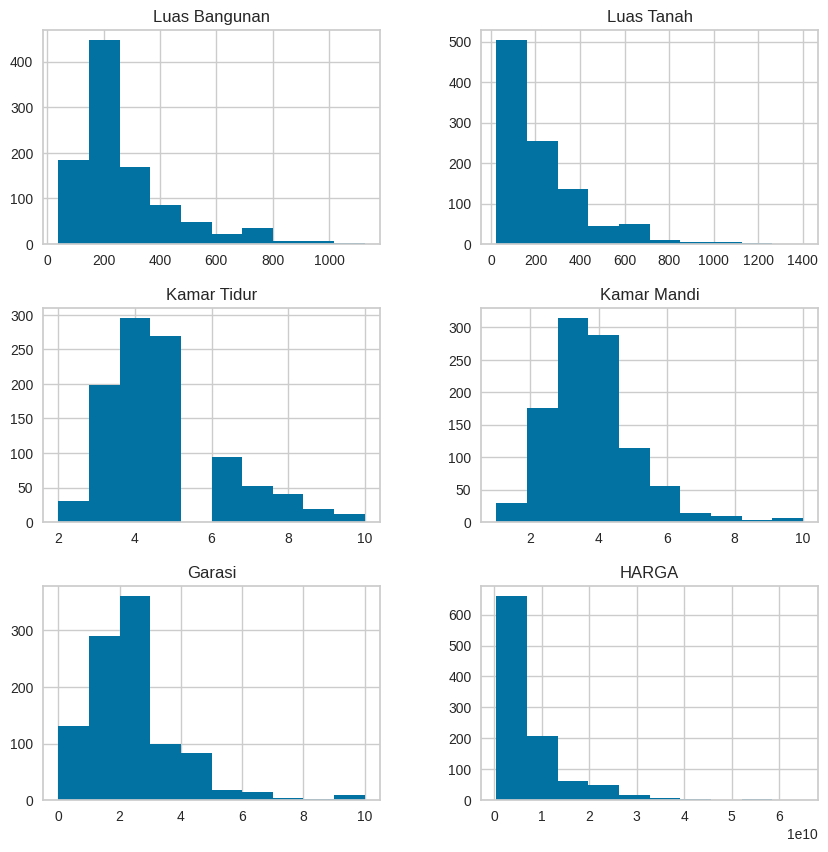

In [59]:
df.hist(figsize = (10,10))
plt.show()

<Axes: >

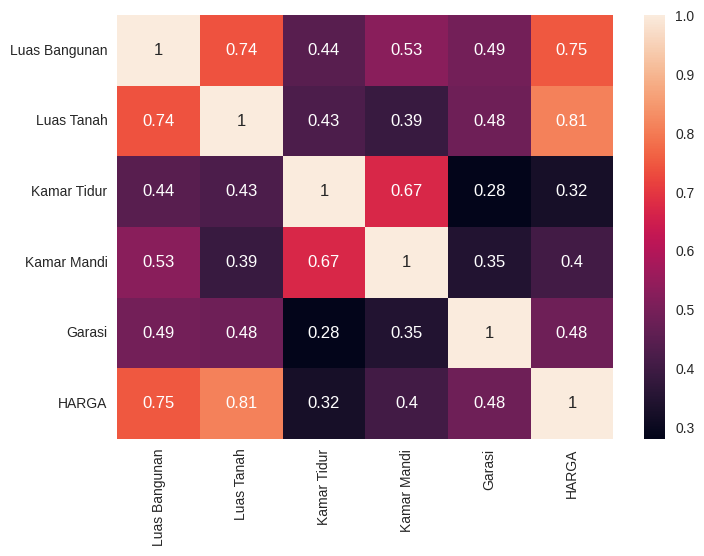

In [56]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

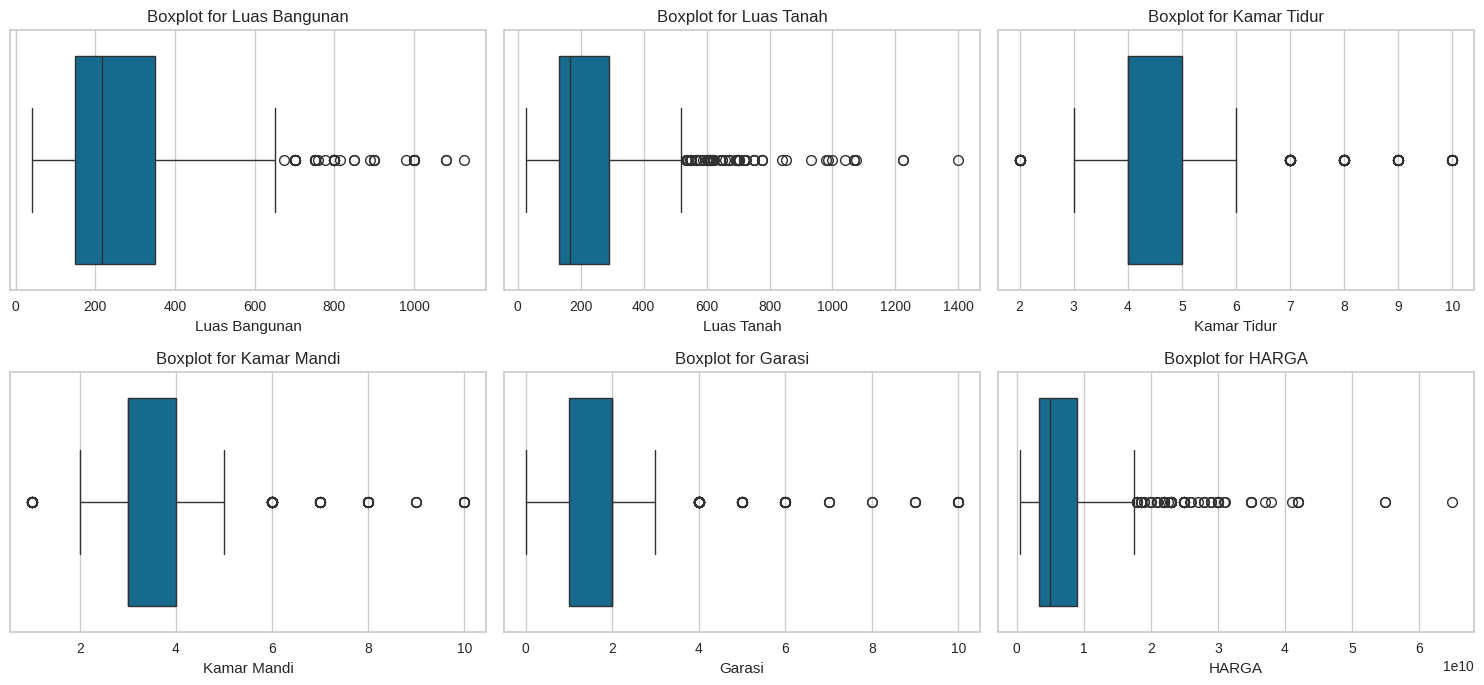

In [61]:
num_rows, num_cols = 3, 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 10))

axes = axes.flatten()

for i, column in enumerate(df.columns):
    sns.boxplot(data=df, x=column, ax=axes[i])
    axes[i].set_title(f'Boxplot for {column}')

for j in range(len(df.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

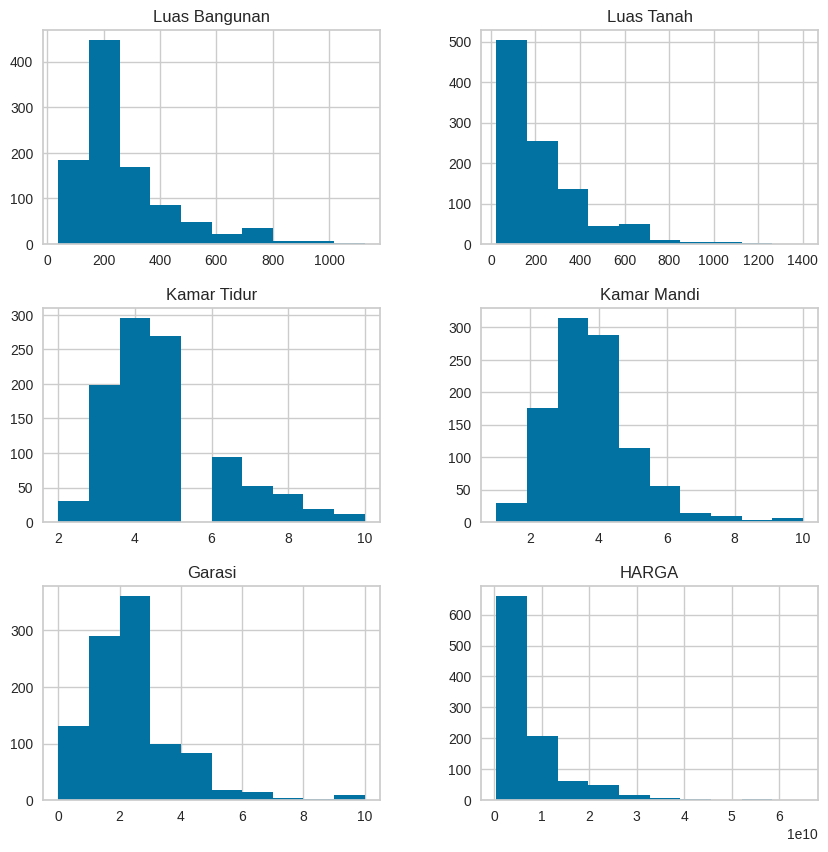

In [64]:
df.hist(figsize = (10,10))
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [63]:
#Drop Kolom
df_processing = df_raw.drop(columns=[
    'NO','NAMA RUMAH'
])

In [66]:
#Ubah Nama Kolom
df_processing.rename(columns={'LB': 'Luas Bangunan',
                   'LT': 'Luas Tanah',
                   'KT': 'Kamar Tidur',
                   'KM': 'Kamar Mandi',
                   'GRS': 'Garasi', }, inplace=True)

In [67]:
#Hapus Data Kosong
df_processing = df_processing.dropna()

In [68]:
#Menghapus Data Duplikat
df_processing = df_processing.drop_duplicates()

In [ ]:
df_processing.to_csv('data_rumah_preprocessing.csv')